# ASAG on Mohler Dataset (MindSpore 1.8.0, GPU Notebook)

This notebook trains an **Automated Short Answer Grading (ASAG)** regression model that predicts a score in **0-5** using:
- question
- reference (desired) answer
- student answer

Dataset target: cleaned **Mohler dataset** (about 2,273 answers across 80 questions).

Pipeline summary:
1. Verify runtime and GPU context (MindSpore 1.8.0 compatible).
2. Load/validate Mohler CSV.
3. Build triple-sequence inputs: `[CLS] question [SEP] reference [SEP] student [SEP]`.
4. Train a two-stage model: encoder + regression head.
5. Evaluate with Pearson, RMSE, MAE, QWK.
6. Save checkpoints, logs, JSON metrics, and MindIR export.

> Compatibility note: The notebook **prefers a pre-trained MindNLP BERT encoder** when available with MindSpore 1.8.0. If unavailable/incompatible, it automatically falls back to a fully compatible local encoder while keeping the same ASAG training flow.

## 0) Optional dependency bootstrap (only if missing)

In [1]:
import importlib
import subprocess
import sys

REQUIRED = {
    "numpy": "numpy",
    "pandas": "pandas",
    "matplotlib": "matplotlib",
    "requests": "requests",
    "sklearn": "scikit-learn",
    "tqdm": "tqdm",
}

def ensure_packages(requirements):
    missing = []
    for module_name, package_name in requirements.items():
        try:
            importlib.import_module(module_name)
        except ImportError:
            missing.append(package_name)
    if missing:
        print("Installing missing packages:", missing)
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q"] + missing)
    else:
        print("All required Python packages are already available.")

ensure_packages(REQUIRED)



All required Python packages are already available.


## 1) Environment check (MindSpore 1.8.0 + GPU)

In [2]:
import os
import platform
import sys
import warnings

import mindspore as ms
from mindspore import context

print("Python:", sys.version.replace("\n", " "))
print("Platform:", platform.platform())
print("MindSpore:", ms.__version__)

# Use GRAPH_MODE for more stable compiled training on MindSpore.
preferred_mode = context.GRAPH_MODE

# Change this if your runtime is actually GPU or CPU.
device_target = "GPU"

try:
    context.set_context(mode=preferred_mode, device_target=device_target)
    active_target = context.get_context("device_target")
    print("Requested device:", device_target)
    print("Active device target:", active_target)
except Exception as dev_err:
    warnings.warn(f"{device_target} setup failed ({dev_err}). Falling back to CPU.")
    context.set_context(mode=preferred_mode, device_target="CPU")
    active_target = context.get_context("device_target")
    print("Active device target:", active_target)

mode_value = context.get_context("mode")
mode_name = "GRAPH_MODE" if mode_value == context.GRAPH_MODE else "PYNATIVE_MODE"
print("Execution mode:", mode_name)

Python: 3.7.5 (default, Jul 21 2022, 12:31:27)  [GCC 7.5.0]
Platform: Linux-6.8.0-101-generic-x86_64-with-debian-buster-sid
MindSpore: 1.8.0
Requested device: GPU
Active device target: GPU
Execution mode: GRAPH_MODE


## 2) Configuration

This cell auto-resolves the ASAG working folder, preferring:
- `/home/xceland/Desktop/Huawei/innovation/application/msmodels/workspace/asag`
- container-friendly equivalents (for example `/workspace/workspace/asag`)


In [3]:
from dataclasses import asdict, dataclass
from pathlib import Path


def resolve_asag_base_dir() -> Path:
    candidates = [
        Path.cwd(),
        Path.cwd() / "workspace" / "asag",
        Path("/workspace/asag"),
        Path("/workspace/workspace/asag"),
        Path("/home/xceland/Desktop/Huawei/innovation/application/msmodels/workspace/asag"),
    ]

    for cand in candidates:
        if (cand / "mohler_dataset_edited.csv").exists():
            return cand.resolve()

    for cand in candidates:
        if cand.exists() and cand.name == "asag":
            return cand.resolve()

    fallback = Path.cwd() / "workspace" / "asag"
    fallback.mkdir(parents=True, exist_ok=True)
    return fallback.resolve()


ASAG_BASE_DIR = resolve_asag_base_dir()


@dataclass
class Config:
    seed: int = 42
    model_name: str = "bert-base-uncased"
    max_length: int = 256
    batch_size: int = 16
    learning_rate: float = 1e-3
    weight_decay: float = 1e-4
    epochs: int = 30
    warmup_ratio: float = 0.1
    patience: int = 7
    val_split: float = 0.2
    max_grad_norm: float = 1.0
    dropout_prob: float = 0.3
    use_amp: bool = False

    local_csv_path: str = str(ASAG_BASE_DIR / "mohler_dataset_edited.csv")
    data_dir: str = str(ASAG_BASE_DIR / "data" / "mohler")
    output_dir: str = str(ASAG_BASE_DIR / "outputs" / "asag_mohler")
    best_ckpt_name: str = "asag_mohler_best.ckpt"
    final_ckpt_name: str = "asag_mohler_final.ckpt"
    mindir_name: str = "asag_mohler"


cfg = Config()

Path(cfg.data_dir).mkdir(parents=True, exist_ok=True)
Path(cfg.output_dir).mkdir(parents=True, exist_ok=True)

print("ASAG base directory:", ASAG_BASE_DIR)
print("Configuration:")
for k, v in asdict(cfg).items():
    print(f"  {k}: {v}")

ASAG base directory: /workspace/workspace/asag
Configuration:
  seed: 42
  model_name: bert-base-uncased
  max_length: 256
  batch_size: 16
  learning_rate: 0.001
  weight_decay: 0.0001
  epochs: 30
  warmup_ratio: 0.1
  patience: 7
  val_split: 0.2
  max_grad_norm: 1.0
  dropout_prob: 0.3
  use_amp: False
  local_csv_path: /workspace/workspace/asag/mohler_dataset_edited.csv
  data_dir: /workspace/workspace/asag/data/mohler
  output_dir: /workspace/workspace/asag/outputs/asag_mohler
  best_ckpt_name: asag_mohler_best.ckpt
  final_ckpt_name: asag_mohler_final.ckpt
  mindir_name: asag_mohler


## 3) Reproducibility

In [4]:
import random
import numpy as np
import mindspore as ms


def set_all_seeds(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    ms.set_seed(seed)

set_all_seeds(cfg.seed)
print(f"Seeds set to {cfg.seed}")



Seeds set to 42


## 4) Dataset download and loading

If `mohler_dataset_edited.csv` is already in the notebook folder, it is used directly.
Otherwise, the notebook tries to download it into `./data/mohler/`.

In [5]:
import json
from pathlib import Path
from typing import Dict, List

import pandas as pd
import requests

CANDIDATE_URLS = [
    "https://raw.githubusercontent.com/ncgamit/Comparative-Evaluation-of-Pretrained-Transfer-Learning-Models-on-ASAG/main/mohler_dataset_edited.csv",
    "https://raw.githubusercontent.com/ncgamit/Comparative-Evaluation-of-Pretrained-Transfer-Learning-Models-on-ASAG/master/mohler_dataset_edited.csv",
    "https://raw.githubusercontent.com/ncgamit/Comparative-Evaluation-of-Pretrained-Transfer-Learning-Models-on-ASAG/main/data/mohler_dataset_edited.csv",
]


def ensure_mohler_csv(local_csv_path: str, data_dir: str) -> Path:
    local_path = Path(local_csv_path)
    fallback_path = Path(data_dir) / "mohler_dataset_edited.csv"

    if local_path.exists():
        print(f"Using local dataset: {local_path.resolve()}")
        return local_path

    if fallback_path.exists():
        print(f"Using cached dataset: {fallback_path.resolve()}")
        return fallback_path

    errors: List[str] = []
    for url in CANDIDATE_URLS:
        try:
            print(f"Downloading from: {url}")
            resp = requests.get(url, timeout=30)
            resp.raise_for_status()
            fallback_path.parent.mkdir(parents=True, exist_ok=True)
            fallback_path.write_bytes(resp.content)
            print(f"Downloaded dataset to: {fallback_path.resolve()}")
            return fallback_path
        except Exception as err:
            errors.append(f"{url} -> {err}")

    raise RuntimeError(
        "Failed to obtain Mohler CSV. Place mohler_dataset_edited.csv in notebook folder.\n"
        + "\n".join(errors)
    )


def resolve_columns(df: pd.DataFrame) -> Dict[str, str]:
    col_map = {c.lower().strip(): c for c in df.columns}

    candidates = {
        "question": ["question", "prompt"],
        "reference_answer": ["desired_answer", "reference_answer", "reference", "model_answer"],
        "student_answer": ["student_answer", "answer", "student_response"],
        "score": ["score_avg", "gold_score", "score", "label", "score_me"],
    }

    resolved = {}
    for standard_name, options in candidates.items():
        hit = None
        for option in options:
            if option in col_map:
                hit = col_map[option]
                break
        if hit is None:
            raise ValueError(
                f"Missing required field for '{standard_name}'. Available columns: {list(df.columns)}"
            )
        resolved[standard_name] = hit

    return resolved

csv_path = ensure_mohler_csv(cfg.local_csv_path, cfg.data_dir)
df_raw = pd.read_csv(csv_path)
print("Raw shape:", df_raw.shape)
print("Raw columns:", list(df_raw.columns))

resolved_cols = resolve_columns(df_raw)
print("Resolved columns:", json.dumps(resolved_cols, indent=2))

df = df_raw.rename(columns={
    resolved_cols["question"]: "question",
    resolved_cols["reference_answer"]: "reference_answer",
    resolved_cols["student_answer"]: "student_answer",
    resolved_cols["score"]: "score",
}).copy()

# Keep only required columns and clean text fields.
df = df[["question", "reference_answer", "student_answer", "score"]]
for col in ["question", "reference_answer", "student_answer"]:
    df[col] = df[col].fillna("").astype(str).str.strip()

# Validate + normalize score range.
df["score"] = pd.to_numeric(df["score"], errors="coerce")
missing_before_drop = df["score"].isna().sum()
if missing_before_drop > 0:
    print(f"Dropping {missing_before_drop} rows with non-numeric score.")
    df = df.dropna(subset=["score"]).reset_index(drop=True)

df["score"] = df["score"].clip(0.0, 5.0)

if df.empty:
    raise ValueError("Dataset is empty after validation.")

print("\nValidated shape:", df.shape)
print("Score range:", (df["score"].min(), df["score"].max()))
print("\nSample rows:")
display(df.head(5))



Using local dataset: /workspace/workspace/asag/mohler_dataset_edited.csv
Raw shape: (2273, 7)
Raw columns: ['id', 'question', 'desired_answer', 'student_answer', 'score_me', 'score_other', 'score_avg']
Resolved columns: {
  "question": "question",
  "reference_answer": "desired_answer",
  "student_answer": "student_answer",
  "score": "score_avg"
}

Validated shape: (2273, 4)
Score range: (0.0, 5.0)

Sample rows:


,question,reference_answer,student_answer,score
0,What is the role of a prototype program in pro...,To simulate the behaviour of portions of the d...,High risk problems are address in the prototyp...,3.5
1,What is the role of a prototype program in pro...,To simulate the behaviour of portions of the d...,To simulate portions of the desired final prod...,5.0
2,What is the role of a prototype program in pro...,To simulate the behaviour of portions of the d...,A prototype program simulates the behaviors of...,4.0
3,What is the role of a prototype program in pro...,To simulate the behaviour of portions of the d...,Defined in the Specification phase a prototype...,5.0
4,What is the role of a prototype program in pro...,To simulate the behaviour of portions of the d...,It is used to let the users have a first idea ...,3.0


## 5) Exploratory inspection

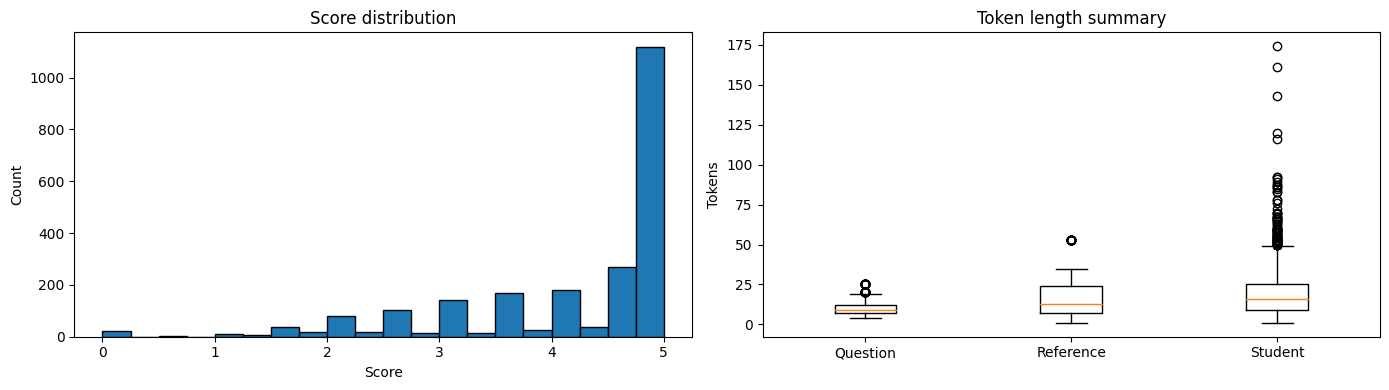

Average lengths:
  question:  9.84
  reference: 15.34
  student:   19.06

Random examples:


,question,reference_answer,student_answer,score
2204,What is the Euler tour traversal of a tree?,"A walk around the tree, starting with the root...",it starts node on the left of the root and the...,3.125
1320,How can you implement a stack with an array?,Keep the top of the stack toward the end of th...,"Make an array, make the bottom at spot 0, make...",4.500
859,What is the number of operations for insertion...,N (the length of the array) operations achieve...,theta(n) the best case senario is that everyth...,4.500


In [6]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(df["score"].values, bins=20, edgecolor="black")
axes[0].set_title("Score distribution")
axes[0].set_xlabel("Score")
axes[0].set_ylabel("Count")

length_stats = {
    "question_len": df["question"].str.split().apply(len),
    "reference_len": df["reference_answer"].str.split().apply(len),
    "student_len": df["student_answer"].str.split().apply(len),
}

axes[1].boxplot(
    [length_stats["question_len"], length_stats["reference_len"], length_stats["student_len"]],
    labels=["Question", "Reference", "Student"],
)
axes[1].set_title("Token length summary")
axes[1].set_ylabel("Tokens")

plt.tight_layout()
plt.show()

print("Average lengths:")
print(f"  question:  {length_stats['question_len'].mean():.2f}")
print(f"  reference: {length_stats['reference_len'].mean():.2f}")
print(f"  student:   {length_stats['student_len'].mean():.2f}")

print("\nRandom examples:")
display(df.sample(3, random_state=cfg.seed))



## 6) Preprocessing and tokenizer setup

Input template (manual triple packing):
`[CLS] question [SEP] reference answer [SEP] student answer [SEP]`

Tokenizer strategy:
1. Try `transformers` BERT tokenizer (`bert-base-uncased`).
2. If unavailable, fall back to a simple local BERT-like tokenizer to keep notebook runnable.

In [7]:
from collections import Counter
from dataclasses import dataclass
from typing import Any, Dict, List, Optional, Sequence, Tuple

import numpy as np
from tqdm.auto import tqdm

SPECIAL_TOKENS = {
    "pad": "[PAD]",
    "unk": "[UNK]",
    "cls": "[CLS]",
    "sep": "[SEP]",
}


class SimpleBertLikeTokenizer:
    def __init__(self, vocab: Dict[str, int]):
        self.vocab = vocab
        self.id_to_token = {v: k for k, v in vocab.items()}
        self.pad_token_id = vocab[SPECIAL_TOKENS["pad"]]
        self.unk_token_id = vocab[SPECIAL_TOKENS["unk"]]
        self.cls_token_id = vocab[SPECIAL_TOKENS["cls"]]
        self.sep_token_id = vocab[SPECIAL_TOKENS["sep"]]
        self.vocab_size = len(vocab)

    @staticmethod
    def _basic_tokenize(text: str) -> List[str]:
        return text.lower().strip().split()

    @classmethod
    def from_texts(cls, texts: Sequence[str], vocab_size: int = 30000) -> "SimpleBertLikeTokenizer":
        counter = Counter()
        for text in texts:
            counter.update(cls._basic_tokenize(str(text)))

        vocab = {
            SPECIAL_TOKENS["pad"]: 0,
            SPECIAL_TOKENS["unk"]: 1,
            SPECIAL_TOKENS["cls"]: 2,
            SPECIAL_TOKENS["sep"]: 3,
        }

        for token, _ in counter.most_common(max(0, vocab_size - len(vocab))):
            if token not in vocab:
                vocab[token] = len(vocab)

        return cls(vocab)

    def encode(self, text: str, add_special_tokens: bool = False) -> List[int]:
        token_ids = [self.vocab.get(t, self.unk_token_id) for t in self._basic_tokenize(text)]
        if add_special_tokens:
            token_ids = [self.cls_token_id] + token_ids + [self.sep_token_id]
        return token_ids

    def save_pretrained(self, save_dir: str) -> None:
        import json
        from pathlib import Path

        path = Path(save_dir)
        path.mkdir(parents=True, exist_ok=True)
        with open(path / "vocab.json", "w", encoding="utf-8") as f:
            json.dump(self.vocab, f, indent=2)


try:
    from transformers import AutoTokenizer
    tokenizer = AutoTokenizer.from_pretrained(cfg.model_name, use_fast=True)
    TOKENIZER_BACKEND = "transformers"
    print(f"Tokenizer backend: {TOKENIZER_BACKEND} ({cfg.model_name})")
except Exception as tok_err:
    print(f"Transformers tokenizer unavailable ({tok_err}). Falling back to simple tokenizer.")
    texts_for_vocab = pd.concat([df["question"], df["reference_answer"], df["student_answer"]]).tolist()
    tokenizer = SimpleBertLikeTokenizer.from_texts(texts_for_vocab, vocab_size=30000)
    TOKENIZER_BACKEND = "simple"
    print(f"Tokenizer backend: {TOKENIZER_BACKEND}, vocab_size={tokenizer.vocab_size}")


def _encode_no_special(tok: Any, text: str) -> List[int]:
    if TOKENIZER_BACKEND == "transformers":
        return tok.encode(text, add_special_tokens=False)
    return tok.encode(text, add_special_tokens=False)


def truncate_three_sequences(a: List[int], b: List[int], c: List[int], max_total: int) -> Tuple[List[int], List[int], List[int]]:
    # Iteratively trim the longest sequence until total length fits.
    while len(a) + len(b) + len(c) > max_total:
        if len(a) >= len(b) and len(a) >= len(c) and len(a) > 0:
            a.pop()
        elif len(b) >= len(a) and len(b) >= len(c) and len(b) > 0:
            b.pop()
        elif len(c) > 0:
            c.pop()
        else:
            break
    return a, b, c


def encode_triplet(
    question: str,
    reference_answer: str,
    student_answer: str,
    tok: Any,
    max_length: int,
) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    q_ids = _encode_no_special(tok, question)
    r_ids = _encode_no_special(tok, reference_answer)
    s_ids = _encode_no_special(tok, student_answer)

    max_payload = max_length - 4  # [CLS] + 3x[SEP]
    q_ids, r_ids, s_ids = truncate_three_sequences(q_ids, r_ids, s_ids, max_payload)

    cls_id = tok.cls_token_id
    sep_id = tok.sep_token_id
    pad_id = tok.pad_token_id

    input_ids = [cls_id] + q_ids + [sep_id] + r_ids + [sep_id] + s_ids + [sep_id]

    # BERT has 2 token_type ids; use 0 for (question + student), 1 for reference.
    token_type_ids = [0] * (1 + len(q_ids) + 1) + [1] * (len(r_ids) + 1) + [0] * (len(s_ids) + 1)
    attention_mask = [1] * len(input_ids)

    pad_len = max_length - len(input_ids)
    if pad_len > 0:
        input_ids += [pad_id] * pad_len
        token_type_ids += [0] * pad_len
        attention_mask += [0] * pad_len

    return (
        np.array(input_ids[:max_length], dtype=np.int32),
        np.array(attention_mask[:max_length], dtype=np.int32),
        np.array(token_type_ids[:max_length], dtype=np.int32),
    )


all_input_ids = np.zeros((len(df), cfg.max_length), dtype=np.int32)
all_attention_mask = np.zeros((len(df), cfg.max_length), dtype=np.int32)
all_token_type_ids = np.zeros((len(df), cfg.max_length), dtype=np.int32)
all_scores = df["score"].astype(np.float32).values

for i, row in tqdm(df.iterrows(), total=len(df), desc="Tokenizing"):
    ids, mask, tt = encode_triplet(
        row["question"],
        row["reference_answer"],
        row["student_answer"],
        tokenizer,
        cfg.max_length,
    )
    all_input_ids[i] = ids
    all_attention_mask[i] = mask
    all_token_type_ids[i] = tt

print("Tokenized tensors:")
print("  input_ids:", all_input_ids.shape)
print("  attention_mask:", all_attention_mask.shape)
print("  token_type_ids:", all_token_type_ids.shape)
print("  score:", all_scores.shape)



/usr/local/python-3.7.5/lib/python3.7/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Transformers tokenizer unavailable (No module named 'transformers'). Falling back to simple tokenizer.
Tokenizer backend: simple, vocab_size=3987


Tokenizing: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████| 2273/2273 [00:00<00:00, 5843.48it/s]

Tokenized tensors:
  input_ids: (2273, 256)
  attention_mask: (2273, 256)
  token_type_ids: (2273, 256)
  score: (2273,)


## 7) Train/validation split (80/20, reproducible, stratified by score bins)

In [8]:
from sklearn.model_selection import train_test_split

# Stratify on rounded scores to keep score distribution similar in each split.
score_bins = np.clip(np.rint(all_scores), 0, 5).astype(int)

indices = np.arange(len(df))
train_idx, val_idx = train_test_split(
    indices,
    test_size=cfg.val_split,
    random_state=cfg.seed,
    stratify=score_bins,
)

print(f"Train size: {len(train_idx)}")
print(f"Val size:   {len(val_idx)}")

X_train = {
    "input_ids": all_input_ids[train_idx],
    "attention_mask": all_attention_mask[train_idx],
    "token_type_ids": all_token_type_ids[train_idx],
    "labels": all_scores[train_idx],
}
X_val = {
    "input_ids": all_input_ids[val_idx],
    "attention_mask": all_attention_mask[val_idx],
    "token_type_ids": all_token_type_ids[val_idx],
    "labels": all_scores[val_idx],
}



Train size: 1818
Val size:   455


## 8) MindSpore dataset pipeline (`GeneratorDataset`)

In [9]:
import mindspore.dataset as ds


class ASAGArrayDataset:
    def __init__(self, arrays):
        self.input_ids = arrays["input_ids"]
        self.attention_mask = arrays["attention_mask"]
        self.token_type_ids = arrays["token_type_ids"]
        self.labels = arrays["labels"]

    def __getitem__(self, idx):
        return (
            self.input_ids[idx],
            self.attention_mask[idx],
            self.token_type_ids[idx],
            self.labels[idx],
        )

    def __len__(self):
        return len(self.labels)


def build_ms_dataset(arrays, batch_size: int, shuffle: bool):
    dataset = ds.GeneratorDataset(
        source=ASAGArrayDataset(arrays),
        column_names=["input_ids", "attention_mask", "token_type_ids", "labels"],
        shuffle=shuffle,
    )
    dataset = dataset.batch(batch_size, drop_remainder=False)
    return dataset

train_dataset = build_ms_dataset(X_train, cfg.batch_size, shuffle=True)
val_dataset = build_ms_dataset(X_val, cfg.batch_size, shuffle=False)

print("Train batches:", train_dataset.get_dataset_size())
print("Val batches:", val_dataset.get_dataset_size())



Train batches: 114
Val batches: 29


In [10]:
print(type(tokenizer))
print(train_dataset.get_dataset_size())
print(val_dataset.get_dataset_size())

<class '__main__.SimpleBertLikeTokenizer'>
114
29


## 9) Model definition (encoder + regression head)

Primary path: pre-trained MindNLP BERT encoder if available.
Fallback path: lightweight local encoder for strict MindSpore 1.8 compatibility.

In [11]:
import mindspore as ms
import mindspore.nn as nn
import mindspore.ops as ops


class FallbackEncoder(nn.Cell):
    """
    Stronger fallback encoder compatible with MindSpore 1.8

    Embedding → BiGRU → projection
    """

    def __init__(self, vocab_size: int, hidden_size: int = 256, emb_size: int = 256):
        super().__init__()

        self.embedding = nn.Embedding(
            vocab_size=vocab_size,
            embedding_size=emb_size,
            padding_idx=0
        )

        # MindSpore 1.x GRU (no batch_first)
        self.bigru = nn.GRU(
            input_size=emb_size,
            hidden_size=hidden_size // 2,
            num_layers=1,
            has_bias=True,
            bidirectional=True
        )

        self.proj = nn.Dense(hidden_size, hidden_size)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(keep_prob=0.9)

        self.transpose = ops.Transpose()

    def construct(self, input_ids, attention_mask=None, token_type_ids=None):

        x = self.embedding(input_ids)          # [B, L, E]

        # convert to [L, B, E]
        x = self.transpose(x, (1, 0, 2))

        x, _ = self.bigru(x)

        # convert back to [B, L, H]
        x = self.transpose(x, (1, 0, 2))

        x = self.proj(x)
        x = self.relu(x)
        x = self.dropout(x)

        return (x,)

In [12]:
from typing import Optional, Tuple

import mindspore as ms
import mindspore.nn as nn
import mindspore.ops as ops


def try_load_mindnlp_encoder(model_name: str) -> Tuple[Optional[nn.Cell], Optional[int], str]:
    errors = []

    try:
        from mindnlp.transformers import BertModel
        encoder = BertModel.from_pretrained(model_name)
        hidden_size = getattr(getattr(encoder, "config", None), "hidden_size", 768)
        return encoder, int(hidden_size), "mindnlp.transformers.BertModel"
    except Exception as err:
        errors.append(f"mindnlp.transformers.BertModel: {err}")

    try:
        from mindnlp.models import BertModel
        encoder = BertModel.from_pretrained(model_name)
        hidden_size = getattr(getattr(encoder, "config", None), "hidden_size", 768)
        return encoder, int(hidden_size), "mindnlp.models.BertModel"
    except Exception as err:
        errors.append(f"mindnlp.models.BertModel: {err}")

    return None, None, " | ".join(errors)


encoder, hidden_size, encoder_backend = try_load_mindnlp_encoder(cfg.model_name)

if encoder is None:
    vocab_size = int(getattr(tokenizer, "vocab_size", 30000))
    hidden_size = 256
    encoder = FallbackEncoder(vocab_size=vocab_size, hidden_size=hidden_size, emb_size=256)
    encoder_backend = f"fallback(BiGRUEncoder, vocab_size={vocab_size})"

print("Encoder backend:", encoder_backend)
print("Hidden size:", hidden_size)


class ASAGRegressor(nn.Cell):
    def __init__(self, encoder: nn.Cell, hidden_size: int, dropout_prob: float = 0.3):
        super().__init__()
        self.encoder = encoder
        self.dropout = nn.Dropout(keep_prob=1.0 - dropout_prob)

        self.fc1 = nn.Dense(hidden_size * 3, hidden_size)
        self.fc2 = nn.Dense(hidden_size, hidden_size // 2)
        self.out = nn.Dense(hidden_size // 2, 1)

        self.relu = nn.ReLU()
        self.cast = ops.Cast()
        self.expand_dims = ops.ExpandDims()
        self.reduce_sum = ops.ReduceSum(keep_dims=False)
        self.reduce_max = ops.ReduceMax(keep_dims=False)
        self.clip_by_value = ops.clip_by_value
        self.squeeze = ops.Squeeze(axis=-1)

    def masked_mean_pool(self, token_embeddings, attention_mask):
        mask = self.cast(attention_mask, ms.float32)
        mask = self.expand_dims(mask, -1)
        masked_embeddings = token_embeddings * mask

        summed = self.reduce_sum(masked_embeddings, 1)
        counts = self.reduce_sum(mask, 1)
        counts = self.clip_by_value(
            counts,
            ms.Tensor(1e-6, ms.float32),
            ms.Tensor(1e9, ms.float32)
        )
        return summed / counts

    def masked_max_pool(self, token_embeddings, attention_mask):
        mask = self.cast(attention_mask, ms.float32)
        mask = self.expand_dims(mask, -1)

        neg_large = ms.Tensor(-1e4, ms.float32)
        masked_embeddings = token_embeddings * mask + (1.0 - mask) * neg_large
        return self.reduce_max(masked_embeddings, 1)

    def construct(self, input_ids, attention_mask, token_type_ids):
        encoder_outputs = self.encoder(input_ids, attention_mask, token_type_ids)
        sequence_output = encoder_outputs[0]

        cls_like = sequence_output[:, 0, :]
        mean_pooled = self.masked_mean_pool(sequence_output, attention_mask)
        max_pooled = self.masked_max_pool(sequence_output, attention_mask)

        features = ops.concat((cls_like, mean_pooled, max_pooled), axis=1)

        x = self.dropout(features)
        x = self.fc1(x)
        x = self.relu(x)
        x = self.dropout(x)

        x = self.fc2(x)
        x = self.relu(x)
        x = self.dropout(x)

        x = self.out(x)
        x = self.squeeze(x)
        return x


model = ASAGRegressor(
    encoder=encoder,
    hidden_size=hidden_size,
    dropout_prob=cfg.dropout_prob
)

print(type(model))
print(model)

Encoder backend: fallback(BiGRUEncoder, vocab_size=3987)
Hidden size: 256
<class '__main__.ASAGRegressor'>
ASAGRegressor<
  (encoder): FallbackEncoder<
    (embedding): Embedding<vocab_size=3987, embedding_size=256, use_one_hot=False, embedding_table=Parameter (name=encoder.embedding.embedding_table, shape=(3987, 256), dtype=Float32, requires_grad=True), dtype=Float32, padding_idx=0>
    (bigru): GRU<
      (rnn): _DynamicGRUCPUGPU<>
      (dropout_op): Dropout<keep_prob=1.0>
      >
    (proj): Dense<input_channels=256, output_channels=256, has_bias=True>
    (relu): ReLU<>
    (dropout): Dropout<keep_prob=0.9>
    >
  (dropout): Dropout<keep_prob=0.7>
  (fc1): Dense<input_channels=768, output_channels=256, has_bias=True>
  (fc2): Dense<input_channels=256, output_channels=128, has_bias=True>
  (out): Dense<input_channels=128, output_channels=1, has_bias=True>
  (relu): ReLU<>
  >


## 10) Loss function (Huber / Smooth L1)

In [13]:
import mindspore.nn as nn
import mindspore.ops as ops


class HuberLoss(nn.Cell):
    def __init__(self, delta: float = 1.0):
        super().__init__()
        self.delta = ms.Tensor(float(delta), ms.float32)
        self.abs = ops.Abs()
        self.minimum = ops.Minimum()
        self.mean = ops.ReduceMean(keep_dims=False)

    def construct(self, preds, targets):
        error = preds - targets
        abs_error = self.abs(error)
        quadratic = self.minimum(abs_error, self.delta)
        linear = abs_error - quadratic
        loss = 0.5 * quadratic * quadratic + self.delta * linear
        return self.mean(loss)


loss_fn = HuberLoss(delta=1.0)
print("Loss:", loss_fn)

Loss: HuberLoss<>


## 11) Optimizer + linear warmup/decay schedule

In [14]:
import mindspore.nn as nn

steps_per_epoch = train_dataset.get_dataset_size()
total_steps = max(1, steps_per_epoch * cfg.epochs)

optimizer = nn.Adam(
    params=model.trainable_params(),
    learning_rate=cfg.learning_rate,
)

print("Steps per epoch:", steps_per_epoch)
print("Total train steps:", total_steps)
print("Learning rate:", cfg.learning_rate)
print("Optimizer: Adam")

Steps per epoch: 114
Total train steps: 3420
Learning rate: 0.001
Optimizer: Adam


## 12) Metrics: Pearson, RMSE, MAE, QWK

In [15]:
from typing import Dict

import numpy as np


def pearson_corr(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    y_true = np.asarray(y_true, dtype=np.float64)
    y_pred = np.asarray(y_pred, dtype=np.float64)
    if y_true.size < 2:
        return 0.0
    if np.std(y_true) < 1e-12 or np.std(y_pred) < 1e-12:
        return 0.0
    return float(np.corrcoef(y_true, y_pred)[0, 1])


def rmse(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    y_true = np.asarray(y_true, dtype=np.float64)
    y_pred = np.asarray(y_pred, dtype=np.float64)
    return float(np.sqrt(np.mean((y_true - y_pred) ** 2)))


def mae(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    y_true = np.asarray(y_true, dtype=np.float64)
    y_pred = np.asarray(y_pred, dtype=np.float64)
    return float(np.mean(np.abs(y_true - y_pred)))


def quadratic_weighted_kappa(y_true: np.ndarray, y_pred: np.ndarray, min_rating: int = 0, max_rating: int = 5) -> float:
    y_true_int = np.clip(np.rint(y_true), min_rating, max_rating).astype(int)
    y_pred_int = np.clip(np.rint(y_pred), min_rating, max_rating).astype(int)

    n_ratings = max_rating - min_rating + 1
    if y_true_int.size == 0:
        return 0.0

    O = np.zeros((n_ratings, n_ratings), dtype=np.float64)
    for a, b in zip(y_true_int, y_pred_int):
        O[a - min_rating, b - min_rating] += 1.0

    hist_true = np.bincount(y_true_int - min_rating, minlength=n_ratings).astype(np.float64)
    hist_pred = np.bincount(y_pred_int - min_rating, minlength=n_ratings).astype(np.float64)

    E = np.outer(hist_true, hist_pred) / max(1.0, float(y_true_int.size))

    W = np.zeros((n_ratings, n_ratings), dtype=np.float64)
    for i in range(n_ratings):
        for j in range(n_ratings):
            W[i, j] = ((i - j) ** 2) / ((n_ratings - 1) ** 2)

    denom = np.sum(W * E)
    if denom <= 1e-12:
        return 0.0

    num = np.sum(W * O)
    return float(1.0 - (num / denom))


def compute_metrics(y_true: np.ndarray, y_pred: np.ndarray) -> Dict[str, float]:
    return {
        "pearson": pearson_corr(y_true, y_pred),
        "rmse": rmse(y_true, y_pred),
        "mae": mae(y_true, y_pred),
        "qwk": quadratic_weighted_kappa(y_true, y_pred, 0, 5),
    }



## 13) Training utilities (loss wrapper, train step with gradient clipping, evaluation)

In [16]:
import json
from pathlib import Path
from typing import Dict, List, Tuple

import numpy as np
import mindspore as ms
import mindspore.nn as nn
import mindspore.ops as ops
from mindspore.ops import composite as C
from mindspore.ops import functional as F


class ASAGWithLoss(nn.Cell):
    def __init__(self, backbone: nn.Cell, criterion: nn.Cell):
        super().__init__()
        self.backbone = backbone
        self.criterion = criterion

    def construct(self, input_ids, attention_mask, token_type_ids, labels):
        preds = self.backbone(input_ids, attention_mask, token_type_ids)
        return self.criterion(preds, labels)


class TrainStepWithClip(nn.Cell):
    def __init__(self, network: nn.Cell, optimizer: nn.Optimizer, max_grad_norm: float = 1.0):
        super().__init__(auto_prefix=False)
        self.network = network
        self.network.set_train()
        self.optimizer = optimizer
        self.weights = ms.ParameterTuple(network.trainable_params())
        self.grad = C.GradOperation(get_by_list=True)
        self.max_grad_norm = float(max_grad_norm)

    def construct(self, input_ids, attention_mask, token_type_ids, labels):
        loss = self.network(input_ids, attention_mask, token_type_ids, labels)
        grads = self.grad(self.network, self.weights)(input_ids, attention_mask, token_type_ids, labels)
        grads = ops.clip_by_global_norm(grads, self.max_grad_norm)
        loss = F.depend(loss, self.optimizer(grads))
        return loss


def evaluate_model(model: nn.Cell, criterion: nn.Cell, dataset) -> Tuple[float, Dict[str, float], np.ndarray, np.ndarray]:
    model.set_train(False)

    all_preds: List[np.ndarray] = []
    all_labels: List[np.ndarray] = []
    val_losses: List[float] = []

    for batch in dataset.create_dict_iterator(num_epochs=1):
        input_ids = batch["input_ids"]
        attention_mask = batch["attention_mask"]
        token_type_ids = batch["token_type_ids"]
        labels = batch["labels"]

        preds = model(input_ids, attention_mask, token_type_ids)
        loss = criterion(preds, labels)

        all_preds.append(preds.asnumpy())
        all_labels.append(labels.asnumpy())
        val_losses.append(float(loss.asnumpy()))

    y_pred = np.concatenate(all_preds, axis=0) if all_preds else np.array([], dtype=np.float32)
    y_true = np.concatenate(all_labels, axis=0) if all_labels else np.array([], dtype=np.float32)

    metrics = compute_metrics(y_true, y_pred)
    avg_val_loss = float(np.mean(val_losses)) if val_losses else float("nan")
    return avg_val_loss, metrics, y_true, y_pred


if cfg.use_amp:
    print("AMP flag is ON, but this notebook keeps FP32 for conservative MindSpore 1.8 compatibility.")

## 14) Training loop (custom notebook loop + early stopping + checkpoints)

In [17]:
from pathlib import Path
import time

loss_network = ASAGWithLoss(model, loss_fn)
train_step = TrainStepWithClip(loss_network, optimizer, max_grad_norm=cfg.max_grad_norm)

output_dir = Path(cfg.output_dir)
best_ckpt_path = output_dir / cfg.best_ckpt_name
final_ckpt_path = output_dir / cfg.final_ckpt_name

history = {
    "train_loss": [],
    "val_loss": [],
    "pearson": [],
    "rmse": [],
    "mae": [],
    "qwk": [],
    "score": [],
}

best_score = -1e9
best_epoch = -1
bad_epochs = 0

for epoch in range(1, cfg.epochs + 1):
    model.set_train(True)
    batch_losses = []

    start_t = time.time()
    for batch in train_dataset.create_dict_iterator(num_epochs=1):
        loss = train_step(
            batch["input_ids"],
            batch["attention_mask"],
            batch["token_type_ids"],
            batch["labels"],
        )
        batch_losses.append(float(loss.asnumpy()))

    train_loss = float(np.mean(batch_losses)) if batch_losses else float("nan")

    val_loss, val_metrics, y_true_val, y_pred_val = evaluate_model(model, loss_fn, val_dataset)

    selection_score = (
        0.6 * val_metrics["pearson"]
        + 0.4 * val_metrics["qwk"]
        - 0.05 * val_metrics["rmse"]
    )

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["pearson"].append(val_metrics["pearson"])
    history["rmse"].append(val_metrics["rmse"])
    history["mae"].append(val_metrics["mae"])
    history["qwk"].append(val_metrics["qwk"])
    history["score"].append(selection_score)

    elapsed = time.time() - start_t
    print(
        f"Epoch {epoch:02d}/{cfg.epochs} | "
        f"train_loss={train_loss:.4f} | val_loss={val_loss:.4f} | "
        f"pearson={val_metrics['pearson']:.4f} | rmse={val_metrics['rmse']:.4f} | "
        f"mae={val_metrics['mae']:.4f} | qwk={val_metrics['qwk']:.4f} | "
        f"score={selection_score:.4f} | time={elapsed:.1f}s"
    )

    if selection_score > best_score:
        best_score = selection_score
        best_epoch = epoch
        bad_epochs = 0
        ms.save_checkpoint(model, str(best_ckpt_path))
        print(f"  -> New best model saved to: {best_ckpt_path}")
    else:
        bad_epochs += 1
        print(f"  -> No improvement. Early-stop counter: {bad_epochs}/{cfg.patience}")

    if bad_epochs >= cfg.patience:
        print("Early stopping triggered.")
        break

ms.save_checkpoint(model, str(final_ckpt_path))
print(f"Final checkpoint saved to: {final_ckpt_path}")
print(f"Best epoch: {best_epoch}, best selection score: {best_score:.4f}")

[ERROR] CORE(80,7e54878d3680,python3.7):2026-03-08-08:00:25.091.424 [mindspore/core/utils/file_utils.cc:253] GetRealPath] Get realpath failed, path[/tmp/ipykernel_80/3913197875.py]
[ERROR] CORE(80,7e54878d3680,python3.7):2026-03-08-08:00:25.092.256 [mindspore/core/utils/file_utils.cc:253] GetRealPath] Get realpath failed, path[/tmp/ipykernel_80/3913197875.py]
[ERROR] CORE(80,7e54878d3680,python3.7):2026-03-08-08:00:25.092.864 [mindspore/core/utils/file_utils.cc:253] GetRealPath] Get realpath failed, path[/tmp/ipykernel_80/3913197875.py]
[ERROR] CORE(80,7e54878d3680,python3.7):2026-03-08-08:00:25.094.053 [mindspore/core/utils/file_utils.cc:253] GetRealPath] Get realpath failed, path[/tmp/ipykernel_80/3913197875.py]
[ERROR] CORE(80,7e54878d3680,python3.7):2026-03-08-08:00:25.098.016 [mindspore/core/utils/file_utils.cc:253] GetRealPath] Get realpath failed, path[/tmp/ipykernel_80/3913197875.py]
[ERROR] CORE(80,7e54878d3680,python3.7):2026-03-08-08:00:25.098.792 [mindspore/core/utils/file_

Epoch 01/30 | train_loss=1.0155 | val_loss=0.6851 | pearson=0.3681 | rmse=1.2522 | mae=1.1223 | qwk=0.1728 | score=0.2274 | time=451.0s
  -> New best model saved to: /workspace/workspace/asag/outputs/asag_mohler/asag_mohler_best.ckpt
Epoch 02/30 | train_loss=0.5195 | val_loss=0.5264 | pearson=0.4224 | rmse=1.0999 | mae=0.9504 | qwk=0.2122 | score=0.2833 | time=2.0s
  -> New best model saved to: /workspace/workspace/asag/outputs/asag_mohler/asag_mohler_best.ckpt
Epoch 03/30 | train_loss=0.4420 | val_loss=0.3859 | pearson=0.4530 | rmse=0.9840 | mae=0.7226 | qwk=0.3156 | score=0.3488 | time=2.1s
  -> New best model saved to: /workspace/workspace/asag/outputs/asag_mohler/asag_mohler_best.ckpt
Epoch 04/30 | train_loss=0.4464 | val_loss=0.4677 | pearson=0.4783 | rmse=1.0421 | mae=0.8723 | qwk=0.3225 | score=0.3639 | time=2.0s
  -> New best model saved to: /workspace/workspace/asag/outputs/asag_mohler/asag_mohler_best.ckpt
Epoch 05/30 | train_loss=0.3671 | val_loss=0.5536 | pearson=0.4896 | r

## 15) Logging and visualization

History saved to: /workspace/workspace/asag/outputs/asag_mohler/history.json


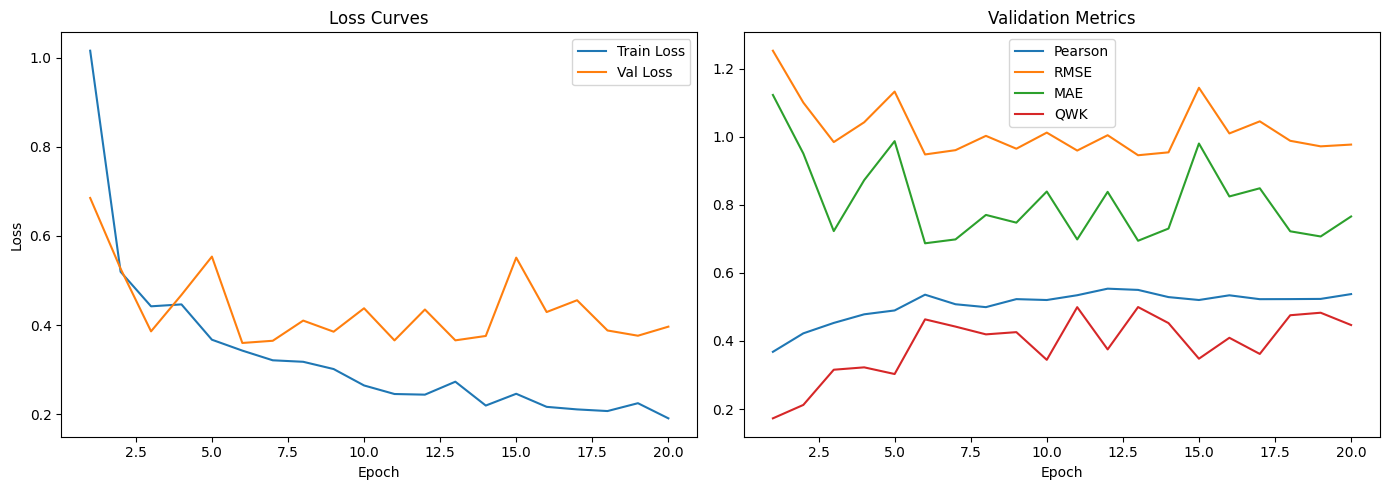

In [18]:
import json
import matplotlib.pyplot as plt
from pathlib import Path

output_dir = Path(cfg.output_dir)
output_dir.mkdir(parents=True, exist_ok=True)

history_path = output_dir / "history.json"
with open(history_path, "w", encoding="utf-8") as f:
    json.dump(history, f, indent=2)

print(f"History saved to: {history_path}")

epochs_axis = range(1, len(history["train_loss"]) + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(epochs_axis, history["train_loss"], label="Train Loss")
axes[0].plot(epochs_axis, history["val_loss"], label="Val Loss")
axes[0].set_title("Loss Curves")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()

axes[1].plot(epochs_axis, history["pearson"], label="Pearson")
axes[1].plot(epochs_axis, history["rmse"], label="RMSE")
axes[1].plot(epochs_axis, history["mae"], label="MAE")
axes[1].plot(epochs_axis, history["qwk"], label="QWK")
axes[1].set_title("Validation Metrics")
axes[1].set_xlabel("Epoch")
axes[1].legend()

plt.tight_layout()
plt.show()



## 16) Evaluation summary and JSON results

In [19]:
from pathlib import Path
import json

best_ckpt_path = Path(cfg.output_dir) / cfg.best_ckpt_name
if best_ckpt_path.exists():
    param_dict = ms.load_checkpoint(str(best_ckpt_path))
    ms.load_param_into_net(model, param_dict)
    print(f"Loaded best checkpoint from: {best_ckpt_path}")
else:
    print("Best checkpoint not found; evaluating current model weights.")

val_loss, final_metrics, y_true_val, y_pred_val = evaluate_model(model, loss_fn, val_dataset)

results = {
    "val_loss": val_loss,
    "pearson": final_metrics["pearson"],
    "rmse": final_metrics["rmse"],
    "mae": final_metrics["mae"],
    "qwk": final_metrics["qwk"],
    "num_val_samples": int(len(y_true_val)),
    "encoder_backend": encoder_backend,
    "tokenizer_backend": TOKENIZER_BACKEND,
    "mindspore_version": ms.__version__,
}

results_path = Path(cfg.output_dir) / "results.json"
with open(results_path, "w", encoding="utf-8") as f:
    json.dump(results, f, indent=2)

print("Final validation metrics:")
for k, v in results.items():
    print(f"  {k}: {v}")
print(f"Results saved to: {results_path}")



Loaded best checkpoint from: /workspace/workspace/asag/outputs/asag_mohler/asag_mohler_best.ckpt
Final validation metrics:
  val_loss: 0.3656973309558013
  pearson: 0.549946135734544
  rmse: 0.9453247484369328
  mae: 0.694230980008513
  qwk: 0.49958998601128757
  num_val_samples: 455
  encoder_backend: fallback(BiGRUEncoder, vocab_size=3987)
  tokenizer_backend: simple
  mindspore_version: 1.8.0
Results saved to: /workspace/workspace/asag/outputs/asag_mohler/results.json


## 17) Export model to MindIR

In [20]:
from pathlib import Path

model.set_train(False)
export_path = Path(cfg.output_dir) / cfg.mindir_name

dummy_input_ids = ms.Tensor(np.zeros((1, cfg.max_length), dtype=np.int32))
dummy_attention_mask = ms.Tensor(np.ones((1, cfg.max_length), dtype=np.int32))
dummy_token_type_ids = ms.Tensor(np.zeros((1, cfg.max_length), dtype=np.int32))

ms.export(
    model,
    dummy_input_ids,
    dummy_attention_mask,
    dummy_token_type_ids,
    file_name=str(export_path),
    file_format="MINDIR",
)

print(f"MindIR exported to: {export_path}.mindir")



[ERROR] CORE(80,7e54878d3680,python3.7):2026-03-08-08:01:11.472.062 [mindspore/core/utils/file_utils.cc:253] GetRealPath] Get realpath failed, path[/tmp/ipykernel_80/3913197875.py]
[ERROR] CORE(80,7e54878d3680,python3.7):2026-03-08-08:01:11.472.787 [mindspore/core/utils/file_utils.cc:253] GetRealPath] Get realpath failed, path[/tmp/ipykernel_80/3913197875.py]
[ERROR] CORE(80,7e54878d3680,python3.7):2026-03-08-08:01:11.473.707 [mindspore/core/utils/file_utils.cc:253] GetRealPath] Get realpath failed, path[/tmp/ipykernel_80/3913197875.py]
[ERROR] CORE(80,7e54878d3680,python3.7):2026-03-08-08:01:11.474.771 [mindspore/core/utils/file_utils.cc:253] GetRealPath] Get realpath failed, path[/tmp/ipykernel_80/3913197875.py]
[ERROR] CORE(80,7e54878d3680,python3.7):2026-03-08-08:01:11.477.626 [mindspore/core/utils/file_utils.cc:253] GetRealPath] Get realpath failed, path[/tmp/ipykernel_80/3913197875.py]
[ERROR] CORE(80,7e54878d3680,python3.7):2026-03-08-08:01:11.478.934 [mindspore/core/utils/file_

MindIR exported to: /workspace/workspace/asag/outputs/asag_mohler/asag_mohler.mindir


## 18) Save tokenizer artifacts

In [21]:
from pathlib import Path

tok_dir = Path(cfg.output_dir) / "tokenizer"
tok_dir.mkdir(parents=True, exist_ok=True)

if hasattr(tokenizer, "save_pretrained"):
    tokenizer.save_pretrained(str(tok_dir))
    print(f"Tokenizer artifacts saved to: {tok_dir}")
else:
    print("Tokenizer has no save_pretrained method; skipping artifact export.")



Tokenizer artifacts saved to: /workspace/workspace/asag/outputs/asag_mohler/tokenizer


## 19) Inference demo

In [22]:
from pathlib import Path


def predict_score(
    model: nn.Cell,
    tokenizer,
    question: str,
    reference_answer: str,
    student_answer: str,
    max_length: int = 256,
) -> float:
    ids, mask, ttype = encode_triplet(question, reference_answer, student_answer, tokenizer, max_length)

    input_ids = ms.Tensor(ids[None, :], ms.int32)
    attention_mask = ms.Tensor(mask[None, :], ms.int32)
    token_type_ids = ms.Tensor(ttype[None, :], ms.int32)

    model.set_train(False)
    pred = model(input_ids, attention_mask, token_type_ids).asnumpy()[0]
    pred = float(np.clip(pred, 0.0, 5.0))
    return pred


# Optional: reload best checkpoint for demo
best_ckpt_path = Path(cfg.output_dir) / cfg.best_ckpt_name
if best_ckpt_path.exists():
    params = ms.load_checkpoint(str(best_ckpt_path))
    ms.load_param_into_net(model, params)

sample_q = "What is the role of a prototype program in problem solving?"
sample_ref = "To simulate the behaviour of portions of the desired software product."
sample_student = "A prototype helps test risky parts and demonstrates whether the solution can be built."

pred_score = predict_score(model, tokenizer, sample_q, sample_ref, sample_student, cfg.max_length)
print(f"Predicted score (clipped 0-5): {pred_score:.3f}")



[ERROR] CORE(80,7e54878d3680,python3.7):2026-03-08-08:01:12.093.740 [mindspore/core/utils/file_utils.cc:253] GetRealPath] Get realpath failed, path[/tmp/ipykernel_80/3913197875.py]
[ERROR] CORE(80,7e54878d3680,python3.7):2026-03-08-08:01:12.094.624 [mindspore/core/utils/file_utils.cc:253] GetRealPath] Get realpath failed, path[/tmp/ipykernel_80/3913197875.py]
[ERROR] CORE(80,7e54878d3680,python3.7):2026-03-08-08:01:12.095.183 [mindspore/core/utils/file_utils.cc:253] GetRealPath] Get realpath failed, path[/tmp/ipykernel_80/3913197875.py]
[ERROR] CORE(80,7e54878d3680,python3.7):2026-03-08-08:01:12.096.263 [mindspore/core/utils/file_utils.cc:253] GetRealPath] Get realpath failed, path[/tmp/ipykernel_80/3913197875.py]
[ERROR] CORE(80,7e54878d3680,python3.7):2026-03-08-08:01:12.098.646 [mindspore/core/utils/file_utils.cc:253] GetRealPath] Get realpath failed, path[/tmp/ipykernel_80/3913197875.py]
[ERROR] CORE(80,7e54878d3680,python3.7):2026-03-08-08:01:12.099.645 [mindspore/core/utils/file_

Predicted score (clipped 0-5): 4.014


## 20) Expected artifacts

Inside `cfg.output_dir` (default `./outputs/asag_mohler`), this notebook writes:
- `asag_mohler_best.ckpt`
- `asag_mohler_final.ckpt`
- `asag_mohler.mindir`
- `history.json`
- `results.json`
- `tokenizer/` artifacts (if supported by tokenizer backend)